In [ ]:
from NeuralNetwork import NeuralNetwork
import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cpu device


In [ ]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [ ]:
# Create a DataLoader for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
# Create model and train
model = NeuralNetwork()
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=1)

100%|██████████| 3000/3000 [00:18<00:00, 162.22it/s]


Epoch 1/1, Train Loss: 0.1825, Val Loss: 0.1426, Val Acc: 0.9622


In [ ]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

KeyboardInterrupt: 

In [ ]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.33%, Validation: 96.18%, Test: 96.25%


In [ ]:
preds = model.predict(test_loader)

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true)

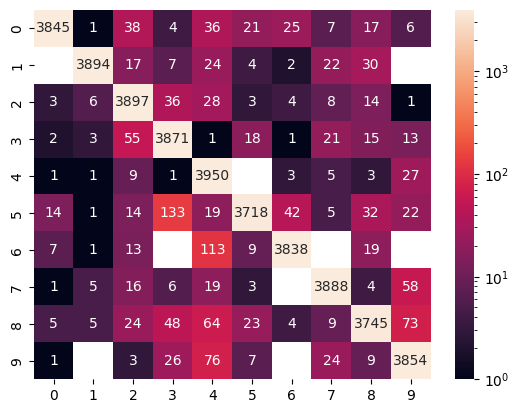

In [ ]:
from matplotlib.colors import LogNorm

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, norm=LogNorm(), annot=True, fmt='d')
plt.show()